# Forecaster Explainability: 
## Feature Importance, SHAP Values, dan Partial Dependence Plots
 
[skforecast explainability guide](https://skforecast.org/0.15.1/user_guides/explainability.html) 

---

---

### Pertanyaan 1: Analisa Prediksi Tentang Apa?

# Analisis Prediksi Permintaan Listrik Harian di Victoria, Australia

Analisis pada notebook ini berfokus pada prediksi **permintaan listrik harian (Electricity Demand)** di negara bagian Victoria, Australia, dengan memanfaatkan metode *time series forecasting* yang dikombinasikan dengan variabel eksternal (*exogenous variables*). Pendekatan ini mempertimbangkan faktor-faktor lain yang dapat memengaruhi perubahan kebutuhan energi dari waktu ke waktu.

Dataset yang digunakan adalah **vic_electricity**, yaitu kumpulan data konsumsi listrik dari jaringan listrik Victoria yang direkam setiap 30 menit. Untuk memudahkan proses analisis dan pemodelan, data tersebut diagregasi menjadi data harian sehingga menghasilkan total permintaan listrik per hari yang direpresentasikan oleh variabel **Demand**. Variabel ini menjadi target utama yang akan diprediksi oleh model karena merepresentasikan tingkat kebutuhan energi listrik masyarakat pada suatu hari tertentu.

Analisis ini juga menggunakan variabel eksternal berupa **Temperature**, yaitu rata-rata suhu harian dalam satuan derajat Celsius (°C). Variabel suhu dipilih karena memiliki hubungan yang erat dengan pola konsumsi energi. Pada saat suhu meningkat, penggunaan perangkat pendingin seperti AC dan kipas angin cenderung bertambah sehingga konsumsi listrik meningkat. Sebaliknya, ketika suhu menurun, penggunaan perangkat pemanas juga dapat menyebabkan kenaikan kebutuhan energi. Oleh karena itu, suhu dianggap sebagai salah satu faktor penting yang dapat membantu meningkatkan akurasi prediksi permintaan listrik.

---

### Pertanyaan 2: Bagaimana Bentuk Data Training-nya?

**INPUT (X_train):** Matriks fitur yang terdiri dari:

| Kolom | Tipe | Penjelasan |
|---|---|---|
| `lag_1` | Numerik | Nilai Demand kemarin (1 hari lalu) |
| `lag_2` | Numerik | Nilai Demand 2 hari lalu |
| `lag_3` | Numerik | Nilai Demand 3 hari lalu |
| `lag_4` | Numerik | Nilai Demand 4 hari lalu |
| `lag_5` | Numerik | Nilai Demand 5 hari lalu |
| `lag_6` | Numerik | Nilai Demand 6 hari lalu |
| `lag_7` | Numerik | Nilai Demand 7 hari lalu |
| `Temperature` | Numerik | Rata-rata suhu pada hari yang sama |

**OUTPUT (y_train):** Kolom `Demand` — nilai permintaan listrik pada hari **t** (hari saat ini yang ingin diprediksi).

> **Ringkasan:** Model belajar: *"Berdasarkan permintaan listrik 7 hari terakhir dan suhu hari ini, berapakah permintaan listrik hari ini?"*

---

### Pertanyaan 3: Apa itu Lag?

**Lag** adalah nilai dari deret waktu (time series) pada titik waktu **sebelumnya** yang digunakan sebagai fitur input untuk model.

**Analogi sederhana:**
> Jika kamu ingin menebak berapa banyak listrik yang dipakai hari ini (Jumat), maka kamu bisa melihat pemakaian listrik hari Kamis (`lag_1`), Rabu (`lag_2`), Selasa (`lag_3`), hingga seminggu ke belakang (`lag_7`).

**Formula matematika:**
```
lag_k(t) = y(t - k)
```
Dimana:
- `y(t)` = nilai target pada waktu t (hari ini)
- `y(t-1)` = lag_1 (kemarin)
- `y(t-7)` = lag_7 (seminggu lalu)

**Kenapa lag penting?**
1. **Autokorelasi:** Data time series seringkali berkorelasi dengan nilai masa lalunya sendiri.
2. **Pola musiman:** Permintaan listrik hari Senin cenderung mirip dengan Senin minggu lalu.
3. **Tanpa lag, model tidak tahu konteks temporal** — ia tidak mengetahui kondisi "kemarin".

**Dalam skforecast:** Parameter `lags=7` artinya model menggunakan 7 lag (lag_1 hingga lag_7) sebagai fitur.

---

### Pertanyaan 4: Proses Analisis yang Dilakukan

Analisis dilakukan melalui **5 tahapan utama**:

| Tahap | Nama | Isi |
|---|---|---|
| 1 | Persiapan Data | Unduh, agregasi, split train-test |
| 2 | Pelatihan Model | ForecasterRecursive + LGBMRegressor + lags=7 |
| 3 | Feature Importance | Kepentingan fitur bawaan LightGBM |
| 4 | Analisis SHAP | Summary, Beeswarm, Force, Dependence plot |
| 5 | Permutation + PDP | Permutation importance & Partial Dependence Plot |

---


## Bagian 1: Instalasi Library dan Import Data

### 1.1 Instalasi dan Import Library

Berikut adalah library yang dibutuhkan dalam analisis ini:
- **`skforecast`**: Framework khusus untuk forecasting time series menggunakan scikit-learn estimators
- **`lightgbm`**: Model gradient boosting berbasis pohon (tree-based) yang cepat dan efisien
- **`shap`**: Library untuk menjelaskan prediksi model machine learning menggunakan Shapley values dari teori permainan (game theory)
- **`sklearn.inspection`**: Modul dari scikit-learn untuk analisis permutation importance dan partial dependence plots


In [1]:
# Libraries
# ==============================================================================
import sys

In [2]:
%pip install skforecast -q
print("library skforecast telah terpasang")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.0 MB/s eta 0:00:00
library skforecast telah terpasang


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


### 1.2 Unduh dan Eksplorasi Dataset

Dataset `vic_electricity` berisi data konsumsi listrik per 30 menit dari jaringan listrik Victoria, Australia.

**Kolom dalam dataset:**
- `Demand` — total permintaan/konsumsi listrik (MWh)
- `Temperature` — suhu udara rata-rata (°C)
- Index berupa datetime (tanggal dan waktu)


In [4]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)


╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


### 1.3 Agregasi ke Frekuensi Harian

Data asli berformat per 30 menit. Untuk menyederhanakan analisis dan mencari pola harian, kita agregasi ke frekuensi **harian**:
- `Demand` → **dijumlahkan** (`sum`): total permintaan listrik per hari (satuan: MWh/hari)
- `Temperature` → **dirata-ratakan** (`mean`): suhu rata-rata per hari (satuan: °C)


In [5]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)


,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


In [7]:
# Cek rentang waktu data
print(f"Data tersedia dari: {data.index.min()}")
print(f"Sampai dengan:      {data.index.max()}")
print(f"Total durasi:       {data.index.max() - data.index.min()}")


Data tersedia dari: 2011-12-31 00:00:00
Sampai dengan:      2014-12-31 00:00:00
Total durasi:       1096 days 00:00:00


### 1.4 Penyesuaian Tanggal (Date Shifting)

Data asli menggunakan tanggal historis lama. Di sini kita menggeser indeks tanggal dimulai dari 2022-04-08 agar lebih relevan dengan konteks masa kini, **tanpa mengubah nilai datanya sama sekali**.

> **Catatan:** Ini hanya mengubah label tanggal pada indeks. Nilai `Demand` dan `Temperature` tidak berubah.


In [8]:
new_dates = pd.date_range(
    start='2022-04-08',
    periods=len(data),
    freq='D'
)

data.index = new_dates

print(f"Data baru tersedia dari: {data.index.min()}")
print(f"Sampai dengan:           {data.index.max()}")
print(f"Total durasi:            {data.index.max() - data.index.min()}")
display(data.head())


Data baru tersedia dari: 2022-04-08 00:00:00
Sampai dengan:           2025-04-08 00:00:00
Total durasi:            1096 days 00:00:00


,Demand,Temperature
2022-04-08,82531.745918,21.047727
2022-04-09,227778.257304,26.578125
2022-04-10,275490.988882,31.751042
2022-04-11,258955.329422,24.567708
2022-04-12,213792.376946,18.191667


### 1.5 Visualisasi Data Awal

Sebelum membuat model, penting untuk memvisualisasikan data agar kita memahami tren dan pola yang ada dalam data time series ini.


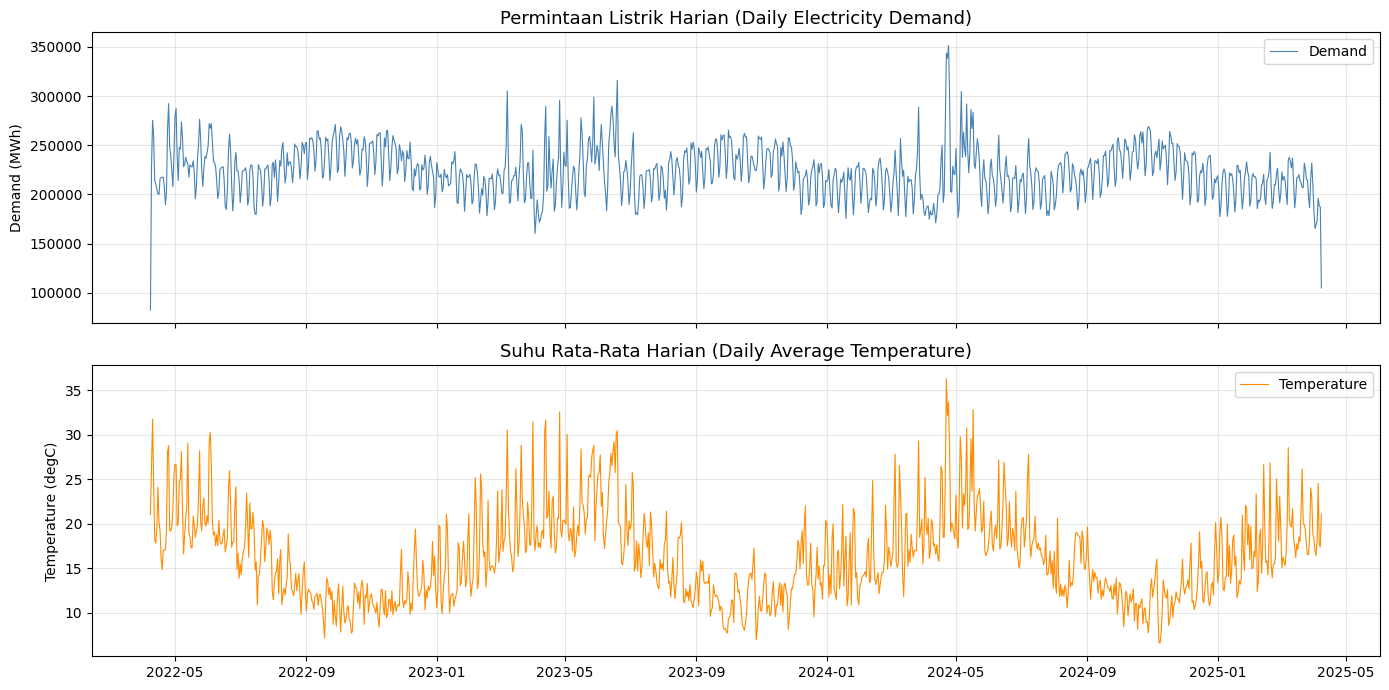

Terlihat pola musiman: permintaan tinggi saat suhu ekstrem (sangat panas atau sangat dingin)


In [9]:
# Visualisasi data time series
# ==============================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(data['Demand'], color='steelblue', linewidth=0.8, label='Demand')
axes[0].set_title('Permintaan Listrik Harian (Daily Electricity Demand)', fontsize=13)
axes[0].set_ylabel('Demand (MWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(data['Temperature'], color='darkorange', linewidth=0.8, label='Temperature')
axes[1].set_title('Suhu Rata-Rata Harian (Daily Average Temperature)', fontsize=13)
axes[1].set_ylabel('Temperature (degC)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Terlihat pola musiman: permintaan tinggi saat suhu ekstrem (sangat panas atau sangat dingin)")


### 1.6 Split Data Training dan Testing

Data dibagi menjadi dua bagian:
- **Training set:** Semua data hingga 26 Mei 2026 — digunakan untuk **melatih model**
- **Test set:** Data mulai 27 Mei 2026 — digunakan untuk **mengevaluasi dan menjelaskan prediksi masa depan**


In [10]:
# Split train-test
# ==============================================================================
data_train = data.loc[:'2026-05-26']
data_test  = data.loc['2026-05-27':]

print(f"Ukuran data training : {data_train.shape} | {data_train.index.min().date()} s/d {data_train.index.max().date()}")
print(f"Ukuran data testing  : {data_test.shape}  | {data_test.index.min().date()} s/d {data_test.index.max().date()}")
print(f"Proporsi train/test  : {len(data_train)/len(data)*100:.1f}% / {len(data_test)/len(data)*100:.1f}%")


Ukuran data training : (1097, 2) | 2022-04-08 s/d 2025-04-08
Ukuran data testing  : (0, 2)  | NaT s/d NaT
Proporsi train/test  : 100.0% / 0.0%


## Bagian 2: Membuat dan Melatih Forecaster

### 2.1 Konsep ForecasterRecursive

`ForecasterRecursive` adalah strategi forecasting multi-langkah di mana:
1. Model dilatih untuk memprediksi **1 langkah ke depan**
2. Untuk prediksi **n langkah ke depan**, hasil prediksi sebelumnya digunakan sebagai lag baru (**recursive/iterated strategy**)

**Komponen model:**
- **Estimator:** `LGBMRegressor` — algoritma gradient boosting berbasis pohon (Light Gradient Boosting Machine)
- **Lags:** 7 — menggunakan 7 hari terakhir sebagai fitur autoregresif
- **Exogenous variables:** `Temperature` — variabel eksternal yang membantu prediksi

### 2.2 Ilustrasi Konsep Lag dalam Training

```
Hari | lag_7 | lag_6 | lag_5 | lag_4 | lag_3 | lag_2 | lag_1 | Temp | TARGET
-----|-------|-------|-------|-------|-------|-------|-------|------|-------
t=8  |  d1   |  d2   |  d3   |  d4   |  d5   |  d6   |  d7   |  T8  |  d8
t=9  |  d2   |  d3   |  d4   |  d5   |  d6   |  d7   |  d8   |  T9  |  d9
t=10 |  d3   |  d4   |  d5   |  d6   |  d7   |  d8   |  d9   |  T10 |  d10
...
```
d = nilai Demand, T = Temperature

### 2.3 Inisialisasi dan Pelatihan Model

In [11]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive

forecaster = ForecasterRecursive(
    estimator=LGBMRegressor(
        random_state=123,
        verbose=-1
    ),
    lags=7
)

forecaster.fit(
    y=data_train['Demand'],
    exog=data_train['Temperature']
)

print("Forecaster berhasil dilatih!")
print(f"Lag yang digunakan   : {forecaster.lags}")
print(f"Estimator            : {type(forecaster.estimator).__name__}")


Forecaster berhasil dilatih!
Lag yang digunakan   : [1 2 3 4 5 6 7]
Estimator            : LGBMRegressor


## Bagian 3: Feature Importance (Bawaan Model LightGBM)

### Apa itu Feature Importance?

Feature importance adalah metrik yang menunjukkan **seberapa berguna atau berharga suatu fitur** dalam membangun pohon keputusan di dalam model. Nilainya dihitung berdasarkan:
- **Gain:** Total penurunan impurity yang disumbangkan fitur saat digunakan sebagai split
- **Split count:** Berapa kali fitur digunakan sebagai titik pemisahan

**Keterbatasan:** Hanya menunjukkan kepentingan global — tidak menjelaskan arah pengaruh (positif/negatif) atau pengaruh per observasi.

### 3.1 Feature Importance (Murni Model)
Ekstraksi nilai kepentingan fitur langsung dari model LightGBM yang mendasarinya.

In [12]:
# Predictors importances
# ==============================================================================
feat_imp = forecaster.get_feature_importances()
print("Tabel Feature Importance:")
display(feat_imp)


Tabel Feature Importance:


,feature,importance
7,Temperature,535
0,lag_1,471
1,lag_2,377
6,lag_7,347
2,lag_3,345
5,lag_6,319
3,lag_4,311
4,lag_5,295


### 3.2 Analisis Predictor Importance
Bagian ini menunjukkan tingkat kepentingan fitur bawaan dari model LightGBM yang digunakan di dalam forecaster.

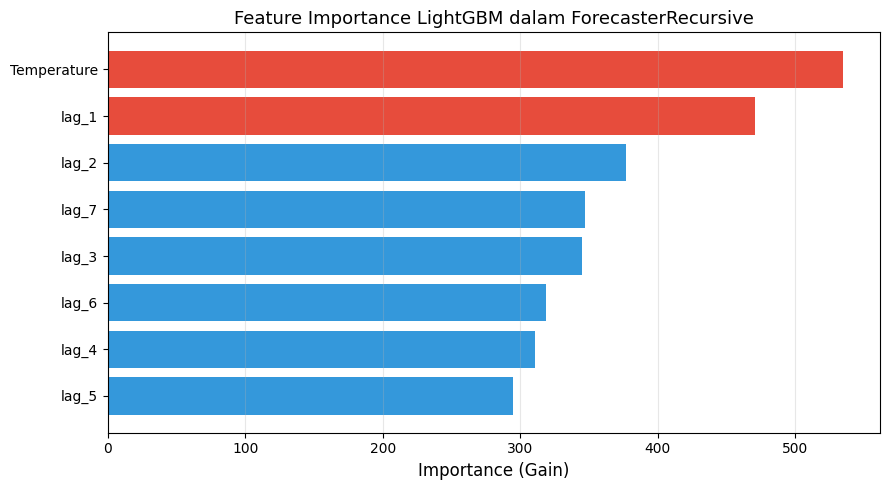

Fitur dengan importance tinggi = lebih sering digunakan model untuk melakukan split
lag_1 (kemarin) biasanya paling penting karena paling dekat dengan hari yang diprediksi


In [13]:
# Visualisasi feature importance
# ==============================================================================
feat_imp_sorted = feat_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if i >= len(feat_imp_sorted)-2 else '#3498db'
          for i in range(len(feat_imp_sorted))]
ax.barh(feat_imp_sorted['feature'], feat_imp_sorted['importance'], color=colors)
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Feature Importance LightGBM dalam ForecasterRecursive', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Fitur dengan importance tinggi = lebih sering digunakan model untuk melakukan split")
print("lag_1 (kemarin) biasanya paling penting karena paling dekat dengan hari yang diprediksi")


## Bagian 4: Matriks Pelatihan (Training Matrix)

### Matriks Pelatihan

Untuk menjalankan SHAP dan analisis lainnya, kita perlu mengakses matriks X (input) dan y (target) yang **benar-benar digunakan model saat training**. Metode `create_train_X_y()` dari skforecast melakukan transformasi data time series menjadi format tabular yang dibutuhkan model ML.

In [14]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

print(f"Ukuran X_train : {X_train.shape}  (baris=sampel, kolom=fitur)")
print(f"Ukuran y_train : {y_train.shape}")
print(f"Kolom X_train  : {X_train.columns.tolist()}")
print()
display(X_train.head(3))
display(y_train.head(3))


Ukuran X_train : (1090, 8)  (baris=sampel, kolom=fitur)
Ukuran y_train : (1090,)
Kolom X_train  : ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'Temperature']



,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2022-04-15,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2022-04-16,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2022-04-17,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
2022-04-15,200693.270298
2022-04-16,200061.614738
2022-04-17,216201.836844


### Penjelasan Struktur Matriks

Perhatikan tabel X_train di atas:
- **Setiap baris** = satu hari observasi
- **lag_1** = nilai Demand dari hari sebelumnya (t-1)
- **lag_7** = nilai Demand dari 7 hari sebelumnya (t-7)
- **Temperature** = suhu rata-rata pada hari t (hari yang diprediksi)
- **y_train** = nilai Demand target pada hari t

Model belajar pola: "Jika riwayat 7 hari terakhir seperti ini dan suhu hari ini sekian, maka Demand hari ini adalah..."

> Catatan: baris pertama X_train valid mulai hari ke-8, karena kita butuh lag_7 = hari ke-1.


In [15]:
# Korelasi antara fitur dan target
# ==============================================================================
corr_matrix = pd.concat([X_train, y_train], axis=1).corr()
print("Korelasi fitur dengan target (Demand):")
print(corr_matrix['y'].drop('y').sort_values(ascending=False).round(4))


Korelasi fitur dengan target (Demand):
lag_1          0.6810
lag_7          0.5681
lag_6          0.4437
lag_2          0.2864
lag_5          0.1972
lag_3          0.1399
lag_4          0.1149
Temperature    0.0339
Name: y, dtype: float64


## Bagian 5: Analisis SHAP (SHapley Additive exPlanations)

### Konsep SHAP

SHAP adalah metode explainability berbasis **Shapley values** dari teori permainan kooperatif (cooperative game theory).

**Ide dasarnya:**
> Bayangkan setiap fitur adalah "pemain" dalam sebuah permainan tim. SHAP mengukur kontribusi setiap pemain terhadap hasil akhir, dengan mempertimbangkan semua kombinasi pemain yang mungkin.

**Formula:**
```
prediksi(x) = base_value + SHAP(lag_1) + SHAP(lag_2) + ... + SHAP(Temperature)
```

**Keunggulan SHAP dibanding Feature Importance biasa:**

| Aspek | Feature Importance | SHAP |
|---|---|---|
| Arah pengaruh (pos/neg) | Tidak ada | Ada |
| Penjelasan per observasi | Global saja | Lokal dan Global |
| Konsistensi matematis | Lebih lemah | Lebih kuat (Shapley axioms) |
| Interaksi antar fitur | Tidak | Bisa dianalisis |

### Persiapan SHAP Explainer
Untuk memahami kontribusi setiap fitur (lag dan temperatur) terhadap prediksi secara individual, kita menggunakan pustaka SHAP yang berbasis pada game theory.

### Analisis SHAP
Implementasi SHAP (SHapley Additive exPlanations) untuk menjelaskan model secara lokal dan global.

In [16]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

print(f"Tipe explainer       : {type(explainer).__name__}")
print(f"Shape SHAP values    : {shap_values.shape}  (sama dengan shape X_train)")
print(f"Base value (E[f(X)]) : {explainer.expected_value:.2f} MWh")
print()
print("Base value = rata-rata prediksi model atas semua data training.")
print("Setiap SHAP value menunjukkan penyimpangan dari base value ini.")


Tipe explainer       : TreeExplainer
Shape SHAP values    : (1090, 8)  (sama dengan shape X_train)
Base value (E[f(X)]) : 223820.31 MWh

Base value = rata-rata prediksi model atas semua data training.
Setiap SHAP value menunjukkan penyimpangan dari base value ini.


### SHAP Summary Plot

**Cara membaca:**
- Sumbu X = rata-rata nilai absolut SHAP (|SHAP|) di semua observasi
- Semakin ke kanan = semakin penting fitur tersebut secara global


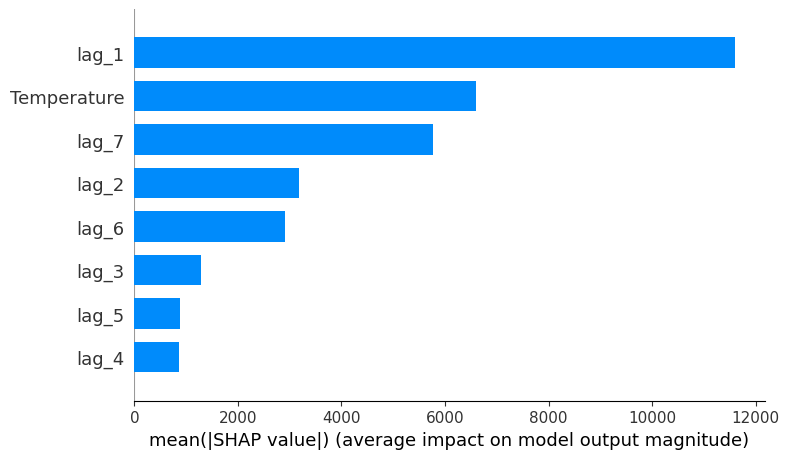

None

In [17]:
from IPython.display import display
display(shap.summary_plot(shap_values, X_train, plot_type="bar"))


### SHAP Bee Swarm Plot

Visualisasi ini merangkum distribusi nilai SHAP untuk setiap fitur, menunjukkan dampak positif atau negatif terhadap prediksi permintaan listrik secara keseluruhan.

**Cara membaca:**
- **Setiap titik** = satu observasi
- **Sumbu X:** nilai SHAP (negatif = menurunkan prediksi, positif = menaikkan prediksi)
- **Warna titik:** nilai fitur yang sebenarnya (biru = rendah, merah = tinggi)
- **Contoh:** Titik merah di kanan pada `Temperature` berarti suhu tinggi cenderung meningkatkan prediksi Demand


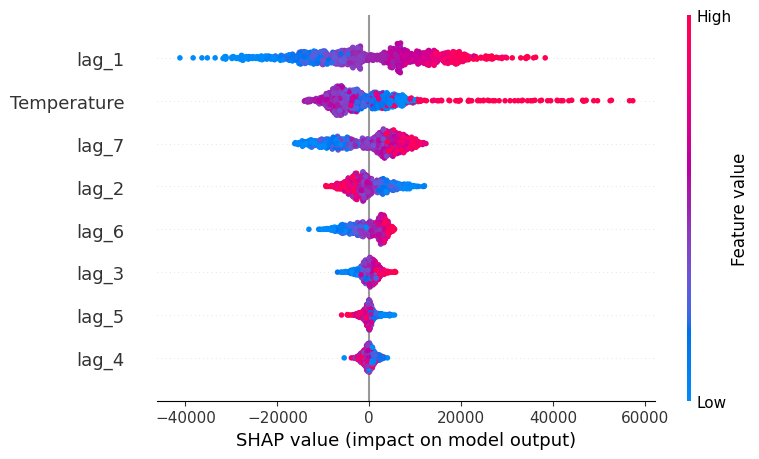

None

In [18]:
from IPython.display import display
display(shap.summary_plot(shap_values, X_train))


### Analisis Observasi Individual (Force Plot)

Kita dapat membedah prediksi tertentu untuk melihat fitur mana yang paling dominan dalam menentukan hasil pada hari tersebut.

### Visualisasi Kontribusi Fitur (Force Plot)

Analisis mendalam pada satu titik observasi untuk melihat bagaimana fitur mempengaruhi prediksi secara spesifik.

### Interpretasi Force Plot

Force plot memberikan visualisasi bagaimana setiap fitur 'mendorong' nilai prediksi menjauh dari nilai dasar (base value). Fitur berwarna **merah** meningkatkan prediksi, sementara **biru** menurunkannya.


Visualize many predictions

In [19]:
# Force plot for the first observation
# ==============================================================================
import shap

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)


In [20]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
import shap
from IPython.display import HTML

shap.initjs()

force = shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

HTML(force.html())


SHAP Dependence Plots

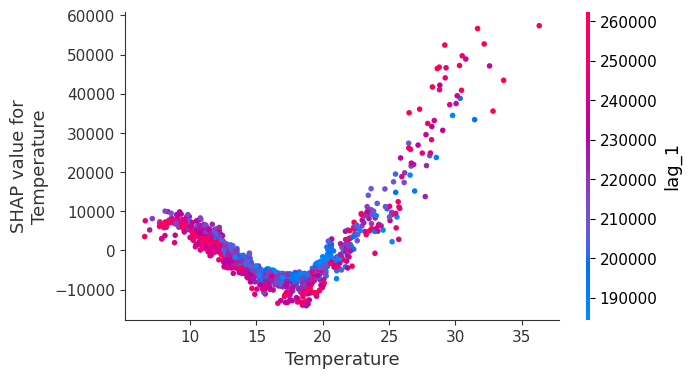

<Figure size 640x480 with 0 Axes>

Titik di atas y=0  -> suhu tersebut meningkatkan prediksi Demand
Titik di bawah y=0 -> suhu tersebut menurunkan prediksi Demand
Pola U = suhu ekstrem (sangat panas ATAU sangat dingin) sama-sama meningkatkan Demand


In [24]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)
ax.set_title("SHAP Dependence Plot: Temperature vs SHAP Value", fontsize=12)
plt.tight_layout()
plt.show()

print("Titik di atas y=0  -> suhu tersebut meningkatkan prediksi Demand")
print("Titik di bawah y=0 -> suhu tersebut menurunkan prediksi Demand")
print("Pola U = suhu ekstrem (sangat panas ATAU sangat dingin) sama-sama meningkatkan Demand")


## Bagian 6: Menjelaskan Prediksi Masa Depan

### Interpretasi Prediksi Masa Depan
Bagian ini fokus pada pemahaman mengapa model membuat prediksi tertentu pada data yang belum pernah dilihat sebelumnya (data uji/forecast). Dengan menganalisis kontribusi setiap fitur terhadap prediksi tersebut (menggunakan matriks input dari create_predict_X), kita dapat memvalidasi apakah alasan di balik prediksi model masuk akal, mengkomunikasikan hasil prediksi kepada pemangku kepentingan, dan mengidentifikasi anomali yang mungkin disebabkan oleh fitur-fitur yang tidak biasa.

Explain forecasted values

In [28]:
# Predict
# ==============================================================================
# Determine the start date for `exog`
last_train_date = data_train.index.max()
start_exog_date = last_train_date + pd.Timedelta(days=1)

# Create a date range for the 10 prediction steps
predict_dates = pd.date_range(start=start_exog_date, periods=10, freq='D')

# Create a placeholder `exog` Series for Temperature
# In a real scenario, these would be actual future temperature forecasts.
placeholder_temperature = data_train['Temperature'].iloc[-1]
exog_predict = pd.Series(placeholder_temperature, index=predict_dates, name='Temperature')

predictions = forecaster.predict(steps=10, exog=exog_predict)
predictions

,pred
2025-04-09,166580.486899
2025-04-10,177411.890312
2025-04-11,179771.769675
2025-04-12,175727.973594
2025-04-13,172602.329754
2025-04-14,168329.971326
2025-04-15,174151.094714
2025-04-16,171740.219698
2025-04-17,177143.078355
2025-04-18,171339.800728


In [30]:
# Create input matrix for predict method
# ==============================================================================
# The original data_test['Temperature'] is empty. We need to use the `exog_predict`
# that was created in the previous cell for the prediction steps.
X_predict = forecaster.create_predict_X(steps=10, exog=exog_predict)
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2025-04-09,104963.021342,187212.226846,188570.258296,196116.228892,173292.325672,168797.125272,165398.200578,21.034615
2025-04-10,166580.486899,104963.021342,187212.226846,188570.258296,196116.228892,173292.325672,168797.125272,21.034615
2025-04-11,177411.890312,166580.486899,104963.021342,187212.226846,188570.258296,196116.228892,173292.325672,21.034615
2025-04-12,179771.769675,177411.890312,166580.486899,104963.021342,187212.226846,188570.258296,196116.228892,21.034615
2025-04-13,175727.973594,179771.769675,177411.890312,166580.486899,104963.021342,187212.226846,188570.258296,21.034615
2025-04-14,172602.329754,175727.973594,179771.769675,177411.890312,166580.486899,104963.021342,187212.226846,21.034615
2025-04-15,168329.971326,172602.329754,175727.973594,179771.769675,177411.890312,166580.486899,104963.021342,21.034615
2025-04-16,174151.094714,168329.971326,172602.329754,175727.973594,179771.769675,177411.890312,166580.486899,21.034615
2025-04-17,171740.219698,174151.094714,168329.971326,172602.329754,175727.973594,179771.769675,177411.890312,21.034615
2025-04-18,177143.078355,171740.219698,174151.094714,168329.971326,172602.329754,175727.973594,179771.769675,21.034615


### Analisis SHAP untuk Prediksi Tertentu

Kita pilih hari pertama prediksi untuk dianalisis lebih dalam.


In [31]:
# Force plot for a specific prediction
# ==============================================================================
from IPython.display import HTML
import shap

shap.initjs()

iloc_predicted_date = 0

# Hitung SHAP values untuk matriks prediksi
shap_values_predict = explainer.shap_values(X_predict)

print(f"Analisis SHAP untuk hari prediksi ke-{iloc_predicted_date+1}:")
print(f"   Tanggal prediksi : {X_predict.index[iloc_predicted_date].date()}")
print(f"   Nilai prediksi   : {predictions.iloc[iloc_predicted_date]:.2f} MWh")
print(f"   Base value       : {explainer.expected_value:.2f} MWh")
print()

# Kontribusi per fitur
shap_detail = pd.DataFrame({
    'Fitur': X_predict.columns,
    'Nilai Fitur': X_predict.iloc[iloc_predicted_date].values,
    'SHAP Value': shap_values_predict[iloc_predicted_date]
}).sort_values('SHAP Value', key=abs, ascending=False)
display(shap_detail)

force = shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

HTML(force.html())


Analisis SHAP untuk hari prediksi ke-1:
   Tanggal prediksi : 2025-04-09
   Nilai prediksi   : 166580.49 MWh
   Base value       : 223820.31 MWh



,Fitur,Nilai Fitur,SHAP Value
0,lag_1,104963.021342,-30650.190012
6,lag_7,165398.200578,-9739.761909
7,Temperature,21.034615,-7108.527371
5,lag_6,168797.125272,-6757.573775
2,lag_3,188570.258296,-2225.020245
1,lag_2,187212.226846,1767.703706
4,lag_5,173292.325672,-1309.296639
3,lag_4,196116.228892,-1217.155093


### Permutation Feature Importance

Metode ini mengukur kepentingan fitur dengan cara mengacak nilai fitur dan melihat seberapa besar penurunan performa model. Ini seringkali lebih stabil dibandingkan feature importance bawaan.

**Cara kerja:**
1. Hitung performa model pada data asli (baseline)
2. Acak (shuffle) nilai satu fitur secara acak — ini "merusak" informasi yang dibawa fitur tersebut
3. Ukur penurunan performa setelah pengacakan
4. Fitur yang menyebabkan penurunan performa paling besar = fitur paling penting

**Formula:**
```
Importance(fitur_j) = Performance_baseline - Performance_setelah_shuffle_fitur_j
```

**Keunggulan:** Lebih model-agnostic, tidak bergantung pada struktur internal model seperti feature importance bawaan.

### Permutation Feature Importance

Metode ini mengukur kepentingan fitur dengan cara mengacak nilai fitur dan melihat seberapa besar penurunan performa model. Ini seringkali lebih stabil dibandingkan feature importance bawaan.

**Cara kerja:**
1. Hitung performa model pada data asli (baseline)
2. Acak (shuffle) nilai satu fitur secara acak — ini "merusak" informasi yang dibawa fitur tersebut
3. Ukur penurunan performa setelah pengacakan
4. Fitur yang menyebabkan penurunan performa paling besar = fitur paling penting

**Formula:**
```
Importance(fitur_j) = Performance_baseline - Performance_setelah_shuffle_fitur_j
```

**Keunggulan:** Lebih model-agnostic, tidak bergantung pada struktur internal model seperti feature importance bawaan.


In [32]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances


,feature,mean_importance,std_importance
0,lag_1,0.642311,0.027934
7,Temperature,0.399183,0.014798
6,lag_7,0.193214,0.008969
1,lag_2,0.124911,0.007665
5,lag_6,0.082380,0.002966
2,lag_3,0.043702,0.001695
3,lag_4,0.032263,0.001327
4,lag_5,0.031363,0.002473


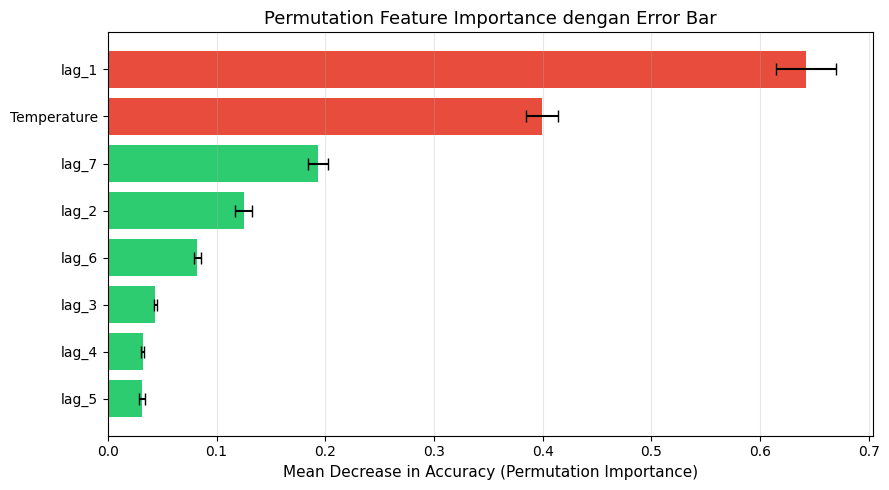

Error bar (garis hitam) = standar deviasi dari 3 pengulangan pengacakan
Semakin kecil error bar = estimasi kepentingan fitur lebih stabil


In [33]:
# Visualisasi Permutation Importance
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
importances_sorted = importances.sort_values('mean_importance', ascending=True)

colors = ['#e74c3c' if i >= len(importances_sorted)-2 else '#2ecc71'
          for i in range(len(importances_sorted))]

ax.barh(importances_sorted['feature'], importances_sorted['mean_importance'],
        xerr=importances_sorted['std_importance'], color=colors, capsize=4)
ax.set_xlabel('Mean Decrease in Accuracy (Permutation Importance)', fontsize=11)
ax.set_title('Permutation Feature Importance dengan Error Bar', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Error bar (garis hitam) = standar deviasi dari 3 pengulangan pengacakan")
print("Semakin kecil error bar = estimasi kepentingan fitur lebih stabil")


### Partial Dependence Plot (PDP)

**PDP** menunjukkan pengaruh **marginal** dari satu fitur terhadap prediksi model, sambil memegang semua fitur lain tetap (pada nilai rata-ratanya).

**Cara kerja:**
1. Pilih satu fitur (misal: Temperature)
2. Untuk setiap nilai pada fitur itu, hitung rata-rata prediksi di seluruh data
3. Plot: nilai fitur vs rata-rata prediksi

**`kind='both'`** menampilkan:
- **PDP (garis tebal):** efek rata-rata marginal
- **ICE lines (garis tipis):** efek per observasi individu (Individual Conditional Expectation)

Jika garis ICE sangat bervariasi = ada interaksi fitur yang kuat.

### Partial Dependence Plot (PDP)

**PDP** menunjukkan pengaruh **marginal** dari satu fitur terhadap prediksi model, sambil memegang semua fitur lain tetap (pada nilai rata-ratanya).

**Cara kerja:**
1. Pilih satu fitur (misal: Temperature)
2. Untuk setiap nilai pada fitur itu, hitung rata-rata prediksi di seluruh data
3. Plot: nilai fitur vs rata-rata prediksi

**`kind='both'`** menampilkan:
- **PDP (garis tebal):** efek rata-rata marginal
- **ICE lines (garis tipis):** efek per observasi individu (Individual Conditional Expectation)

Jika garis ICE sangat bervariasi = ada interaksi fitur yang kuat.


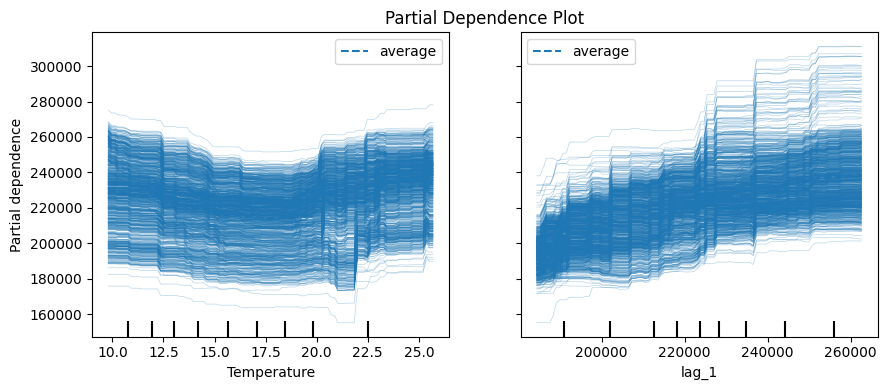

In [34]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();


## Bagian 7: Perbandingan Semua Metode Explainability

Kita rangkum ranking fitur dari ketiga metode yang telah digunakan untuk melihat konsistensinya:

In [35]:
# Perbandingan ranking fitur dari 3 metode
# ==============================================================================

# 1. Feature Importance (LightGBM)
feat_imp_df = forecaster.get_feature_importances().set_index('feature')['importance']
feat_imp_norm = (feat_imp_df / feat_imp_df.sum() * 100).rename('LightGBM FI (%)')

# 2. SHAP (mean absolute SHAP value)
shap_mean = pd.Series(
    abs(shap_values).mean(axis=0),
    index=X_train.columns
).rename('Mean |SHAP|')

# 3. Permutation Importance
perm_df = importances.set_index('feature')['mean_importance'].rename('Permutation Imp')

# Gabungkan semua metode
comparison = pd.concat([feat_imp_norm, shap_mean, perm_df], axis=1).fillna(0)
comparison_sorted = comparison.sort_values('Mean |SHAP|', ascending=False)

print("Perbandingan Ranking Fitur dari 3 Metode Explainability:")
display(comparison_sorted.round(4))

print()
print("Jika ketiga metode menunjukkan ranking yang konsisten -> hasil lebih dapat dipercaya")


Perbandingan Ranking Fitur dari 3 Metode Explainability:


,LightGBM FI (%),Mean |SHAP|,Permutation Imp
lag_1,15.7000,11590.6150,0.6423
Temperature,17.8333,6606.3356,0.3992
lag_7,11.5667,5775.2699,0.1932
lag_2,12.5667,3188.1693,0.1249
lag_6,10.6333,2900.4521,0.0824
lag_3,11.5000,1283.7549,0.0437
lag_5,9.8333,891.1986,0.0314
lag_4,10.3667,868.6516,0.0323



Jika ketiga metode menunjukkan ranking yang konsisten -> hasil lebih dapat dipercaya


## Kesimpulan

Berdasarkan berbagai metode interpretabilitas (Feature Importance, SHAP, dan PDP), kita dapat menyimpulkan bahwa **Temperature** dan **Lag_1** adalah faktor penentu utama dalam fluktuasi permintaan listrik di dataset ini.

---

### Rangkuman Jawaban Pertanyaan

**1. Analisis prediksi tentang apa?**
Prediksi permintaan listrik harian (Electricity Demand dalam MWh) di Victoria, Australia, menggunakan ForecasterRecursive + LGBMRegressor. Fokus utama adalah **menjelaskan model** bukan sekadar memprediksi.

**2. Bentuk data training:**
- **Input (X_train):** 8 kolom — `lag_1` sampai `lag_7` (nilai Demand 7 hari sebelumnya) + `Temperature` (suhu hari yang diprediksi)
- **Output (y_train):** 1 kolom — `Demand` pada hari t

**3. Apa itu Lag?**
Lag adalah nilai historis dari deret waktu yang digunakan sebagai fitur. `lag_k(t) = y(t-k)`. Misalnya `lag_1` = nilai kemarin, `lag_7` = nilai seminggu lalu. Lag memungkinkan model menangkap pola autokorelasi dan musiman dalam data.

**4. Proses analisis yang dilakukan:**

| Tahap | Metode | Temuan |
|---|---|---|
| 1 | Persiapan Data | Agregasi harian, split train-test |
| 2 | Pelatihan Model | ForecasterRecursive + LGBMRegressor + lags=7 |
| 3 | Feature Importance | lag_1 dan Temperature paling penting |
| 4a | SHAP Summary Bar | Konfirmasi kepentingan global |
| 4b | SHAP Beeswarm | Arah pengaruh: suhu tinggi meningkatkan Demand |
| 4c | SHAP Force Plot | Penjelasan prediksi individual per hari |
| 4d | SHAP Dependence | Pola U suhu: ekstrem panas/dingin tingkatkan Demand |
| 5 | Permutation Importance | Konfirmasi kepentingan fitur secara robust |
| 6 | PDP | Efek marginal Temperature dan lag_1 terhadap Demand |

**Temuan utama:** `lag_1` dan `Temperature` adalah prediktor paling kuat. Ketiga metode (Feature Importance, SHAP, Permutation) memberikan ranking yang konsisten, menunjukkan hasil yang robust.
